In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kiểu hiển thị cho biểu đồ
plt.style.use('ggplot')

# 1. Đọc và kiểm tra dữ liệu
file_path = 'orders_with_5_items.csv'
data = pd.read_csv(file_path)


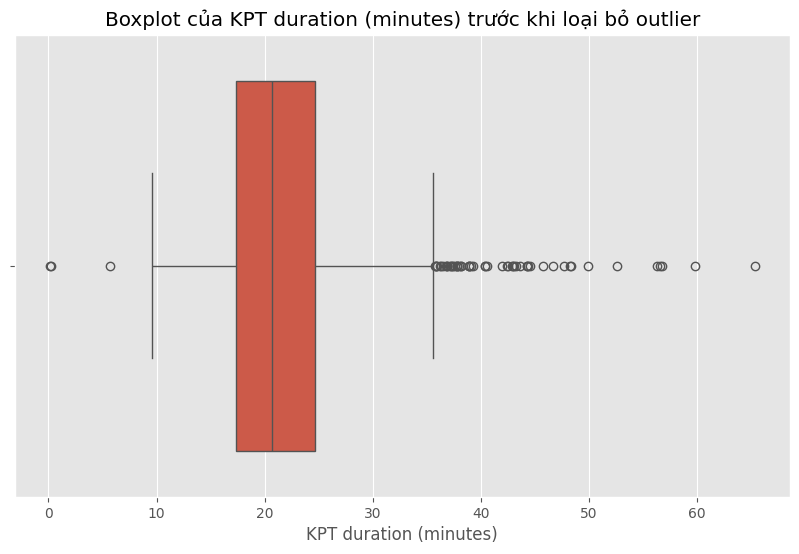

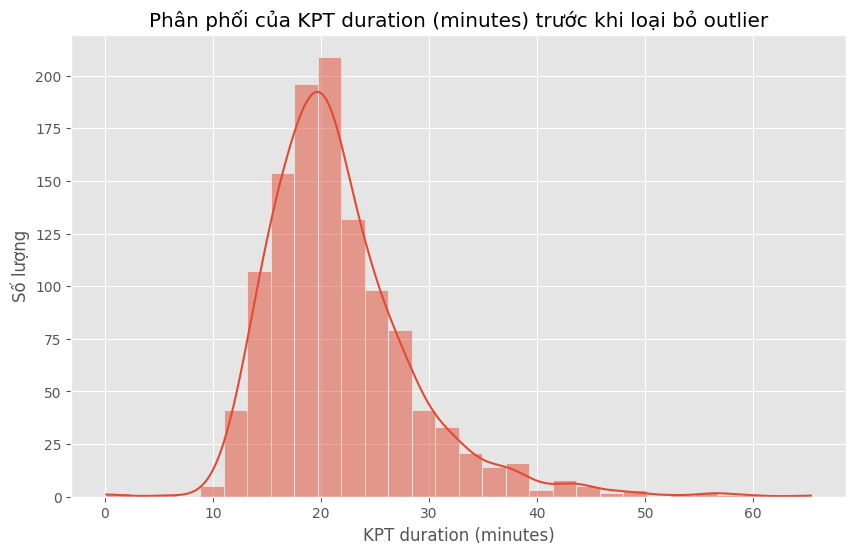

In [27]:

# 2. Hiển thị phân phối ban đầu
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['KPT duration (minutes)'])
plt.title('Boxplot của KPT duration (minutes) trước khi loại bỏ outlier')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data['KPT duration (minutes)'], bins=30, kde=True)
plt.title('Phân phối của KPT duration (minutes) trước khi loại bỏ outlier')
plt.xlabel('KPT duration (minutes)')
plt.ylabel('Số lượng')
plt.show()


In [28]:

# 3. Loại bỏ outlier bằng IQR
def remove_outliers(df, column='KPT duration (minutes)'):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}')
    print(f'Lower bound: {lower_bound}, Upper bound: {upper_bound}')
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

data_cleaned = remove_outliers(data)
print(f'Số dòng trước khi loại bỏ outlier: {len(data)}')
print(f'Số dòng sau khi loại bỏ outlier: {len(data_cleaned)}')


Q1: 17.35, Q3: 24.67, IQR: 7.32
Lower bound: 6.370000000000001, Upper bound: 35.650000000000006
Số dòng trước khi loại bỏ outlier: 1176
Số dòng sau khi loại bỏ outlier: 1120


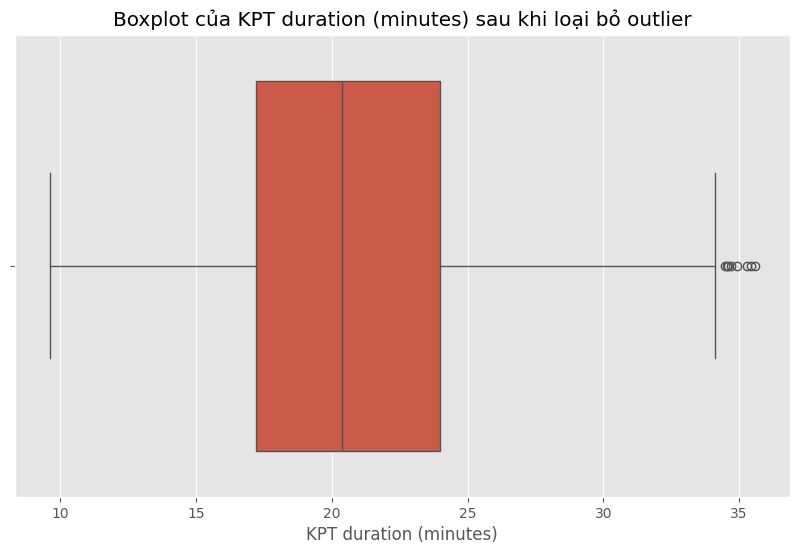

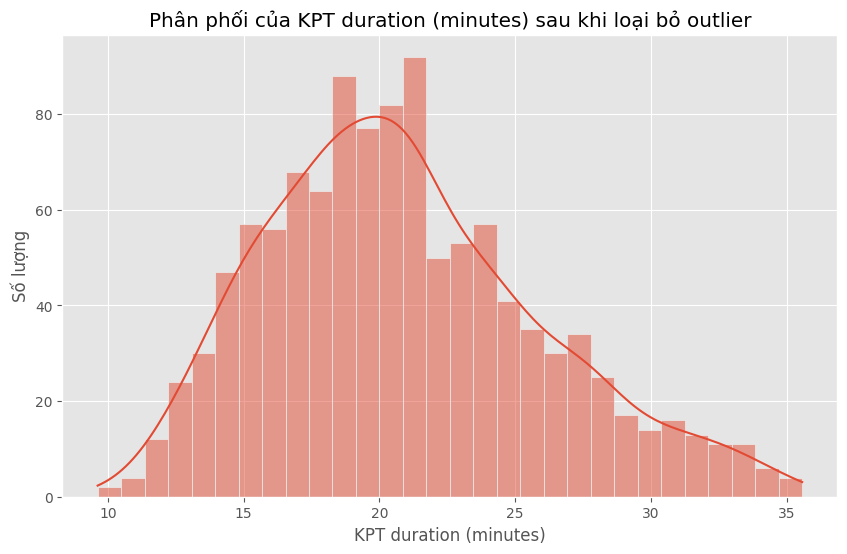


Thống kê mô tả của KPT duration (minutes) sau khi loại bỏ outlier:
count    1120.000000
mean       20.861661
std         5.059386
min         9.620000
25%        17.220000
50%        20.365000
75%        23.980000
max        35.570000
Name: KPT duration (minutes), dtype: float64


In [29]:

# 4. Hiển thị phân phối sau khi loại bỏ outlier
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_cleaned['KPT duration (minutes)'])
plt.title('Boxplot của KPT duration (minutes) sau khi loại bỏ outlier')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data_cleaned['KPT duration (minutes)'], bins=30, kde=True)
plt.title('Phân phối của KPT duration (minutes) sau khi loại bỏ outlier')
plt.xlabel('KPT duration (minutes)')
plt.ylabel('Số lượng')
plt.show()

print('\nThống kê mô tả của KPT duration (minutes) sau khi loại bỏ outlier:')
print(data_cleaned['KPT duration (minutes)'].describe())


In [ ]:

# 5. Lưu dữ liệu sạch
output_path = 'cleaned_orders_with_5_items.csv'
data_cleaned.to_csv(output_path, index=False)
print(f'Đã lưu dữ liệu sạch vào: {output_path}')

Đã lưu dữ liệu sạch vào: cleaned_orders_with_4_items.csv
